In [117]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:

# Pipeline:
#  Define a neural net
#  Create a dataset to train on. Standard classifier example, or maybe XOR (or both)
#  Create a function script which enables either Cross-entropy or Direction loss function [ESSENTIAL]
#  Training model on the dataset on set of training points (very few -> 100% accuracy) [ESSENTIAL]

## Standard libraries
import numpy as np
import pickle
import yaml
from functools import partial

import matplotlib.pyplot as plt

## Progress bar
from tqdm.auto import tqdm

#ML Libraries
import jax
import optax

import os

import torch.utils.data as data

# Custom Libraries
from counterfactual_alignment.custom_models   import SimpleClassifier, SimpleClassifier_v2, MLP, CNN,  GSPaper, GSPaperNew, GSPaper2, GSPaper3, BagOfWordsClassifier, BagOfWordsClassifierSimple, BagOfWordsClassifierSingle
from counterfactual_alignment.custom_datasets import customDataset, genCustomDataset
from counterfactual_alignment.custom_datasets import datasets as custom_datasets
from counterfactual_alignment.loss_functions import loss_functions
from counterfactual_alignment.knowledge_functions import knowledge_functions
from counterfactual_alignment.knowledge_functions import counterfactual_vector_paths, counterfactual_feasible_vector_paths, counterfactual_breadcrumbs
import  counterfactual_alignment.utilities  as ut

import torch
import seaborn as sns


In [119]:

# Get the directory where THIS script is located
"""
# project_dir = os.path.dirname(os.path.abspath(__file__))

with open(os.path.join(project_dir,'config.yaml'),'r') as file:
    config = yaml.unsafe_load(file)
"""
with open('config.yaml','r') as file:
    config = yaml.unsafe_load(file)
"""
Generate DATASET
"""
data_name = config['data_params']['dataset']

train = genCustomDataset(custom_datasets[data_name],config['data_params']['train_size'],None,
                         train=True,
                         visualise=config['visualisation']['visualise'],
                         seed=config['hyperparams']['seed'],
                         n_vec = config['data_params']['n_vec'])


In [120]:

normal_pal = sns.color_palette("Set1",(len(np.unique(train.Y))+1)*2)
pastel_pal = sns.color_palette("Pastel1",(len(np.unique(train.Y))+1)*2)
normal_pal.as_hex()
pastel_pal.as_hex()


['#fbb4ae', '#b3cde3', '#ccebc5', '#decbe4', '#fed9a6', '#ffffcc']

In [121]:

validation = genCustomDataset(custom_datasets[data_name],config['data_params']['validation_size'],None,
                         train=False,
                         visualise=config['visualisation']['visualise'],
                         seed=config['hyperparams']['seed'],
                         n_vec = config['data_params']['n_vec'])

0
for Class 0 in classes [np.int64(0), np.int64(1)]
for point [-0.4387079  -0.87143976] in [array([-0.4387079 , -0.87143976]), array([ 0.16121647, -0.98649489]), array([ 0.98504641, -0.14797152]), array([ 0.59762334, -0.82823899]), array([ 0.8195029 , -0.57428626]), array([-0.00799169,  0.99996454]), array([ 0.95618246, -0.3106956 ]), array([0.96451988, 0.30286207]), array([ 0.69967641, -0.69694742]), array([ 0.44843895, -0.88664393]), array([-0.7096898 ,  0.72549834]), array([-0.99522264,  0.15733393]), array([-0.60073748, -0.80827153]), array([-0.9774943 , -0.16629314]), array([0.88657702, 0.46944574]), array([-0.8124058 , -0.58957781]), array([0.30660752, 0.94857953]), array([-0.89269172,  0.45972759]), array([ 0.99043227, -0.00651523]), array([0.4441549 , 0.89180781]), array([-0.46131576,  0.89774466]), array([-0.95540561, -0.31925203]), array([ 0.31029266, -0.9438771 ]), array([ 0.00388936, -0.98928558]), array([-0.89672476, -0.43967461]), array([0.80059151, 0.58258679]), array([-

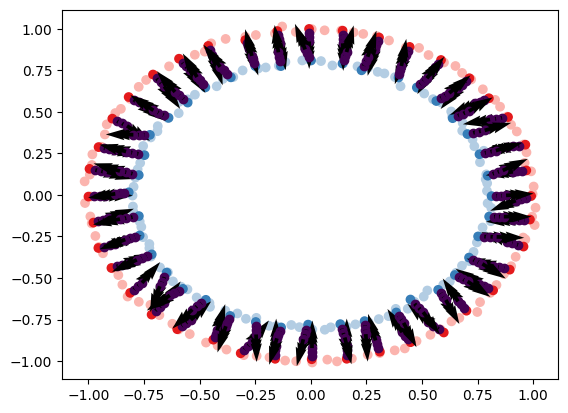

In [122]:
KX = []
KY = []
KK = []

classes = list(np.unique(train.Y))
n_classes = len(classes)
n_points = len(train.X)

plt.scatter(validation.X[:,0],validation.X[:,1],c = [pastel_pal[y] for y in validation.Y])
plt.scatter(train.X[:,0],train.X[:,1], c = [normal_pal[y] for y in train.Y])
for class_i in classes:
    print(class_i)
    print(f"for Class {class_i} in classes {classes}")
    for point in [train.X[i] for i, y in enumerate(train.Y) if y == class_i]:
        print(f'for point {point} in {[train.X[i] for i, y in enumerate(train.Y) if y == class_i]}')
        
        other_classes = [classes[i] for i, x in enumerate(classes) if x != class_i]
        
        KX_i = []
        KY_i = []
        KK_i = []

        breadcrumbs  = counterfactual_breadcrumbs(train.X[train.X==point],
                                                    classifier = train.data.optimum_classifier,
                                                    Z = validation.X,
                                                    n_breadcrumbs=3)
        print(breadcrumbs)

        # for other_class in other_classes:
        #     print(f'for {other_class} in {other_classes}')
            
        #     idx = np.random.choice([i for i, x in enumerate(train.Y) if x == other_class])
        #     print('point 1',train.X[train.X==point])
        #     print('point 2',train.X[idx])

        #     breadcrumbs  = counterfactual_breadcrumbs(train.X[train.X==point],
                                                        
        #                                                 classifier = train.data.optimum_classifier,
        #                                                 Z = validation.X,
        #                                                 n_breadcrumbs=3)
            
            
        #     for i,o in enumerate(breadcrumbs['origins']):
        #         plt.scatter(o[0],o[1],c = breadcrumbs['labels'][i] )
        #         plt.quiver(o[0],o[1],breadcrumbs['vectors'][i][0],breadcrumbs['vectors'][i][1])
                
        #     i = 0
        #     selected_class = breadcrumbs['labels'][i]
        #     print(f'Selected class: {selected_class}')
        #     print(f"while selected class: {class_i}")

        #     KX_i.append(breadcrumbs['origins'][i])
        #     # KY_i.append(breadcrumbs['labels'][i])
        #     KY_i.append(class_i)
        #     KK_i.append(breadcrumbs['origins'][i] + breadcrumbs['vectors'][i])
            
        #     while selected_class == class_i:
        #         i += 1

        #         print(f" selected class: {selected_class}")
        #         print(breadcrumbs['labels'])
        #         print("I: ",i)
        #         selected_class = breadcrumbs['labels'][i]
                # KX_i.append(breadcrumbs['origins'][i])
                # # KY_i.append(breadcrumbs['labels'][i])
                # KY_i.append(class_i)
                # KK_i.append(breadcrumbs['origins'][i] + breadcrumbs['vectors'][i])
        for i,o in enumerate(breadcrumbs['origins']):
            plt.scatter(o[0],o[1],c = breadcrumbs['labels'][i] )
            plt.quiver(o[0],o[1],breadcrumbs['vectors'][i][0],breadcrumbs['vectors'][i][1])
        KX_i.append(breadcrumbs['origins'])
        # KY_i.append(breadcrumbs['labels'][i])
        KY_i.append(class_i*np.ones_like(breadcrumbs['labels']))
        KK_i.append(breadcrumbs['origins'] + breadcrumbs['vectors'])
                

        KX.append(np.array(KX_i))
        KY.append(np.array(KY_i))
        KK.append(np.array(KK_i))
        
                    

In [123]:
train.K = {'X': KX,
           'Y': KY,
           'K': KK}

In [124]:
KX

[array([[[-0.43300301, -0.85296821],
         [-0.42729812, -0.83449667],
         [-0.42159323, -0.81602513]]]),
 array([[[ 0.16123207, -0.96109561],
         [ 0.16124766, -0.93569634],
         [ 0.16126326, -0.91029706]]]),
 array([[[ 0.96035731, -0.14933898],
         [ 0.93566821, -0.15070645],
         [ 0.91097911, -0.15207391]]]),
 array([[[ 0.57413757, -0.80748554],
         [ 0.55065179, -0.78673208],
         [ 0.52716601, -0.76597862]]]),
 array([[[ 0.7981302 , -0.56068599],
         [ 0.77675749, -0.54708571],
         [ 0.75538478, -0.53348544]]]),
 array([[[-0.00793001,  0.97483378],
         [-0.00786833,  0.94970301],
         [-0.00780665,  0.92457225]]]),
 array([[[ 0.93138622, -0.30130903],
         [ 0.90658999, -0.29192247],
         [ 0.88179375, -0.2825359 ]]]),
 array([[[0.93697624, 0.2974798 ],
         [0.90943259, 0.29209753],
         [0.88188895, 0.28671526]]]),
 array([[[ 0.68714566, -0.678261  ],
         [ 0.67461491, -0.65957459],
         [ 0.6620841

In [125]:
print([K[:,:,0] for K in train.K["X"]])

[array([[-0.43300301, -0.42729812, -0.42159323]]), array([[0.16123207, 0.16124766, 0.16126326]]), array([[0.96035731, 0.93566821, 0.91097911]]), array([[0.57413757, 0.55065179, 0.52716601]]), array([[0.7981302 , 0.77675749, 0.75538478]]), array([[-0.00793001, -0.00786833, -0.00780665]]), array([[0.93138622, 0.90658999, 0.88179375]]), array([[0.93697624, 0.90943259, 0.88188895]]), array([[0.68714566, 0.67461491, 0.66208416]]), array([[0.43580489, 0.42317084, 0.41053679]]), array([[-0.69278932, -0.67588884, -0.65898836]]), array([[-0.96890874, -0.94259484, -0.91628094]]), array([[-0.58044962, -0.56016176, -0.5398739 ]]), array([[-0.9555134 , -0.93353249, -0.91155159]]), array([[0.85959782, 0.83261862, 0.80563942]]), array([[-0.79471675, -0.7770277 , -0.75933864]]), array([[0.30026091, 0.2939143 , 0.28756769]]), array([[-0.87067359, -0.84865546, -0.82663734]]), array([[0.96743555, 0.94443883, 0.92144212]]), array([[0.43587839, 0.42760189, 0.41932538]]), array([[-0.45261001, -0.44390426, -

In [126]:
np.concat([K[:,0] for K in train.K['X']])

array([[-0.43300301, -0.85296821],
       [ 0.16123207, -0.96109561],
       [ 0.96035731, -0.14933898],
       [ 0.57413757, -0.80748554],
       [ 0.7981302 , -0.56068599],
       [-0.00793001,  0.97483378],
       [ 0.93138622, -0.30130903],
       [ 0.93697624,  0.2974798 ],
       [ 0.68714566, -0.678261  ],
       [ 0.43580489, -0.8666523 ],
       [-0.69278932,  0.70159958],
       [-0.96890874,  0.15060965],
       [-0.58044962, -0.78975978],
       [-0.9555134 , -0.15799763],
       [ 0.85959782,  0.46465167],
       [-0.79471675, -0.56941599],
       [ 0.30026091,  0.92503029],
       [-0.87067359,  0.44530774],
       [ 0.96743555, -0.01564098],
       [ 0.43587839,  0.86887043],
       [-0.45261001,  0.87129193],
       [-0.92975029, -0.31094678],
       [ 0.30387519, -0.92122163],
       [ 0.00423881, -0.96682906],
       [-0.87348089, -0.43070207],
       [ 0.77966252,  0.57275791],
       [-0.57668759,  0.79744284],
       [-0.15998862, -0.96139882],
       [-0.29834296,

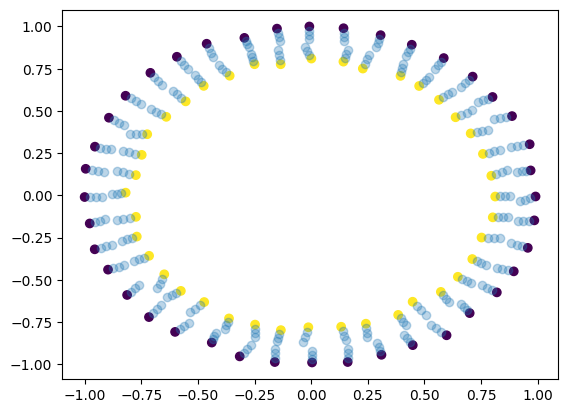

In [127]:
# plt.scatter(breadcrumbs['origins'][:,0],breadcrumbs['origins'][:,1])
# plt.scatter(train.X[train.X==point][0],train.X[train.X==point][1],color='green')
plt.scatter(train.X[:,0],train.X[:,1],c=train.Y)
plt.scatter(np.concat([K[:,:,0] for K in train.K['X']]),np.concat([K[:,:,1] for K in train.K['X']]),alpha=0.3)

In [128]:
np.shape(train.K['K'])

(80, 1, 3, 2)

In [129]:
train.K['K']

[array([[[-0.13790912,  0.10250005],
         [-0.13220423,  0.12097159],
         [-0.12649934,  0.13944313]]]),
 array([[[0.16184612, 0.0389042 ],
         [0.16186172, 0.06430347],
         [0.16187732, 0.08970275]]]),
 array([[[-0.03811233, -0.20464159],
         [-0.06280143, -0.20600905],
         [-0.08749053, -0.20737652]]]),
 array([[[-0.1752139 , -0.14531306],
         [-0.19869967, -0.1245596 ],
         [-0.22218545, -0.10380614]]]),
 array([[[-0.04554096, -0.02382569],
         [-0.06691367, -0.01022542],
         [-0.08828638,  0.00337485]]]),
 array([[[-0.00547563, -0.02516321],
         [-0.00541395, -0.05029398],
         [-0.00535227, -0.07542474]]]),
 array([[[-0.00384749,  0.05272191],
         [-0.02864372,  0.06210847],
         [-0.05343996,  0.07149504]]]),
 array([[[-0.04446139,  0.1056982 ],
         [-0.07200503,  0.10031593],
         [-0.09954868,  0.09493366]]]),
 array([[[0.13019688, 0.15228584],
         [0.11766613, 0.17097226],
         [0.10513538, 0.

In [130]:
np.shape(train.K['Y'])

(80, 1, 3)

In [131]:
np.concat(train.K['K'],axis=1)

array([[[-1.37909116e-01,  1.02500046e-01],
        [-1.32204228e-01,  1.20971588e-01],
        [-1.26499341e-01,  1.39443130e-01],
        [ 1.61846124e-01,  3.89041984e-02],
        [ 1.61861721e-01,  6.43034737e-02],
        [ 1.61877318e-01,  8.97027491e-02],
        [-3.81123335e-02, -2.04641588e-01],
        [-6.28014339e-02, -2.06009052e-01],
        [-8.74905343e-02, -2.07376516e-01],
        [-1.75213895e-01, -1.45313061e-01],
        [-1.98699671e-01, -1.24559602e-01],
        [-2.22185447e-01, -1.03806144e-01],
        [-4.55409635e-02, -2.38256930e-02],
        [-6.69136714e-02, -1.02254198e-02],
        [-8.82863793e-02,  3.37485330e-03],
        [-5.47562640e-03, -2.51632104e-02],
        [-5.41394576e-03, -5.02939766e-02],
        [-5.35226513e-03, -7.54247428e-02],
        [-3.84748565e-03,  5.27219055e-02],
        [-2.86437233e-02,  6.21084741e-02],
        [-5.34399610e-02,  7.14950426e-02],
        [-4.44613917e-02,  1.05698201e-01],
        [-7.20050347e-02,  1.003

In [132]:
print([(key,np.concat(val,axis=1)) for key, val in train.K.items()])

[('X', array([[[-0.43300301, -0.85296821],
        [-0.42729812, -0.83449667],
        [-0.42159323, -0.81602513],
        [ 0.16123207, -0.96109561],
        [ 0.16124766, -0.93569634],
        [ 0.16126326, -0.91029706],
        [ 0.96035731, -0.14933898],
        [ 0.93566821, -0.15070645],
        [ 0.91097911, -0.15207391],
        [ 0.57413757, -0.80748554],
        [ 0.55065179, -0.78673208],
        [ 0.52716601, -0.76597862],
        [ 0.7981302 , -0.56068599],
        [ 0.77675749, -0.54708571],
        [ 0.75538478, -0.53348544],
        [-0.00793001,  0.97483378],
        [-0.00786833,  0.94970301],
        [-0.00780665,  0.92457225],
        [ 0.93138622, -0.30130903],
        [ 0.90658999, -0.29192247],
        [ 0.88179375, -0.2825359 ],
        [ 0.93697624,  0.2974798 ],
        [ 0.90943259,  0.29209753],
        [ 0.88188895,  0.28671526],
        [ 0.68714566, -0.678261  ],
        [ 0.67461491, -0.65957459],
        [ 0.66208416, -0.64088817],
        [ 0.43580489,

In [133]:
colors = np.where(train.Y == 0, "tab:red", "tab:blue")




plot_K = {
            dict_key: np.concat(val,axis=1)[0]
            for dict_key, val in train.K.items()
        }


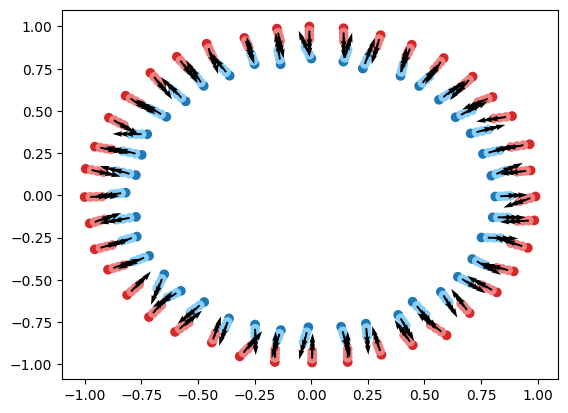

In [134]:
k_colors=np.where(plot_K['Y']==0, "lightcoral", "lightskyblue")
# train.data.optimum_classifier([train.K['X'][:,0],train.K['X'][:,1]])
plt.scatter(train.X[:,0],train.X[:,1],c=colors)


x = plot_K['X'][:,0]
y = plot_K['X'][:,1]
u = plot_K['K'][:,0] - x
v = plot_K['K'][:,1] - y
plt.scatter(x,y,c=k_colors)

plt.quiver(x,y,u,v)

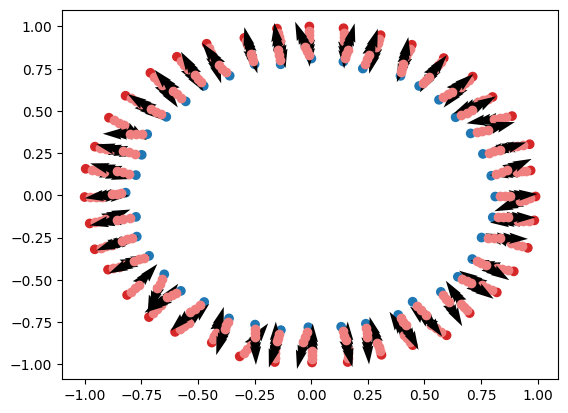

In [135]:
colors = np.where(train.Y == 0, "tab:red", "tab:blue")


# train.data.optimum_classifier([train.K['X'][:,0],train.K['X'][:,1]])
plt.scatter(train.X[:,0],train.X[:,1],c=colors)
k_colors=np.where(plot_K['Y']==0, "lightcoral", "lightskyblue")
for i in range(len(train.K['X'])):
    
    x = train.K['X'][i][:,:,0]
    y = train.K['X'][i][:,:,1]
    u = train.K['K'][i][:,:,0] - x
    v = train.K['K'][i][:,:,1] - y

    plt.quiver(x,y,u,v)
    plt.scatter(x,y,c=k_colors[i])
    

In [136]:
output_path = "outputs/" + data_name + "/"
os.makedirs(output_path, exist_ok=True)

"""
Initialise Parameters
"""

n_models = 6
n_epochs = config['hyperparams']['epochs']
overwrite = True

n_vectors = len(train.X[0])

rng = jax.random.PRNGKey(42)

rng, inp_rng, init_rng, dropout_rng, embedding_rng = jax.random.split(rng, 5)

loss_function = partial(loss_functions[config['hyperparams']['loss_function']], alpha=config['hyperparams']['loss_mix'])

In [137]:
"""
Model Parameters
"""
loss_name = config['hyperparams']['loss_function'] # "direction", 'cross_entropy_batch', 'cross_entropy_l2', 'direction', 'direction_interactive' & more - see loss functions
learning_rate = config['hyperparams']['learning_rate']
batch_size = config['hyperparams']['batch_size']


warmup_steps = 100
peak_lr = 1.0
final_lr = 1e-3

schedule = optax.join_schedules(
    schedules=[
        optax.linear_schedule(init_value=0.0, end_value=peak_lr, transition_steps=warmup_steps),
        optax.exponential_decay(init_value=peak_lr, transition_steps=100, decay_rate=0.9)
    ],
    boundaries=[warmup_steps]
)

# optimiser = optax.adam(schedule)

optimiser = optax.chain(
    optax.clip_by_global_norm(1.0),  # Clip gradients
    optax.adam(schedule)
)


# Define a learning rate schedule (e.g., exponential decay)
learning_rate_schedule = optax.exponential_decay(
    init_value=1,  # Starting learning rate
    transition_steps=50,  
    decay_rate=0.9,  # Decay factor
    transition_begin=10,  # When to start the decay
    staircase=False  # Set to True for a staircase effect
)

sgd_opt = optax.sgd(learning_rate=0.01,momentum=0.8 )
adam_opt = optax.adam(learning_rate=learning_rate)
scheduled_adadelta = optax.adadelta(learning_rate=learning_rate_schedule, weight_decay=0.05)
adamw = optax.adamw(
    learning_rate=1e-3,
    b1=0.9,
    b2=0.999,
    eps=1e-8,
    weight_decay=0.0
)
adadelta = optax.adadelta(
    learning_rate=1,    # default
    rho=0.95,              # decay rate
    eps=1e-6
)
scheduled_adadelta = optax.adadelta(learning_rate=learning_rate_schedule, weight_decay=0.05)

# optimiser = adamw
# optimiser = scheduled_adadelta
# optimiser = adadelta
optimiser = adam_opt

optim_name = [oname for oname in [name for name, value in locals().items() if value is optimiser] if oname != 'optimiser'][0]


In [138]:


ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80


In [139]:


for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":train.X,
            "Y":train.Y,
            "K":train.K.copy()
        }
        
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_function,rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name  + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)


# Get the directory where THIS script is located
project_dir = ""



  2%|▏         | 2/100 [00:00<00:16,  5.89it/s]

Train | Loss: 0.691867, Accuracy: 50.00%
Validation | Loss: 0.691843, Accuracy: 50.00%
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80
Train | Loss: 0.691768, Accuracy: 50.00%
Validation | Loss: 0.691746, Accuracy: 50.00%


  4%|▍         | 4/100 [00:00<00:16,  5.94it/s]

Train | Loss: 0.691669, Accuracy: 50.00%
Validation | Loss: 0.69165, Accuracy: 50.00%
Train | Loss: 0.691572, Accuracy: 50.00%
Validation | Loss: 0.691554, Accuracy: 50.00%


  6%|▌         | 6/100 [00:00<00:15,  6.08it/s]

...

Train | Loss: 0.680478, Accuracy: 60.00%
Validation | Loss: 0.680546, Accuracy: 60.00%
Train | Loss: 0.680332, Accuracy: 60.00%
Validation | Loss: 0.6804, Accuracy: 60.00%
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80


 98%|█████████▊| 98/100 [00:17<00:00,  5.87it/s]

Train | Loss: 0.680186, Accuracy: 60.00%
Validation | Loss: 0.680253, Accuracy: 60.00%
Train | Loss: 0.68004, Accuracy: 60.00%
Validation | Loss: 0.680105, Accuracy: 60.00%


100%|██████████| 100/100 [00:17<00:00,  5.64it/s]

Train | Loss: 0.679894, Accuracy: 60.00%
Validation | Loss: 0.679957, Accuracy: 60.50%
Train | Loss: 0.679749, Accuracy: 60.00%
Validation | Loss: 0.67981, Accuracy: 60.00%
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80


In [140]:

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          project_dir = project_dir,
          plot_type='video')



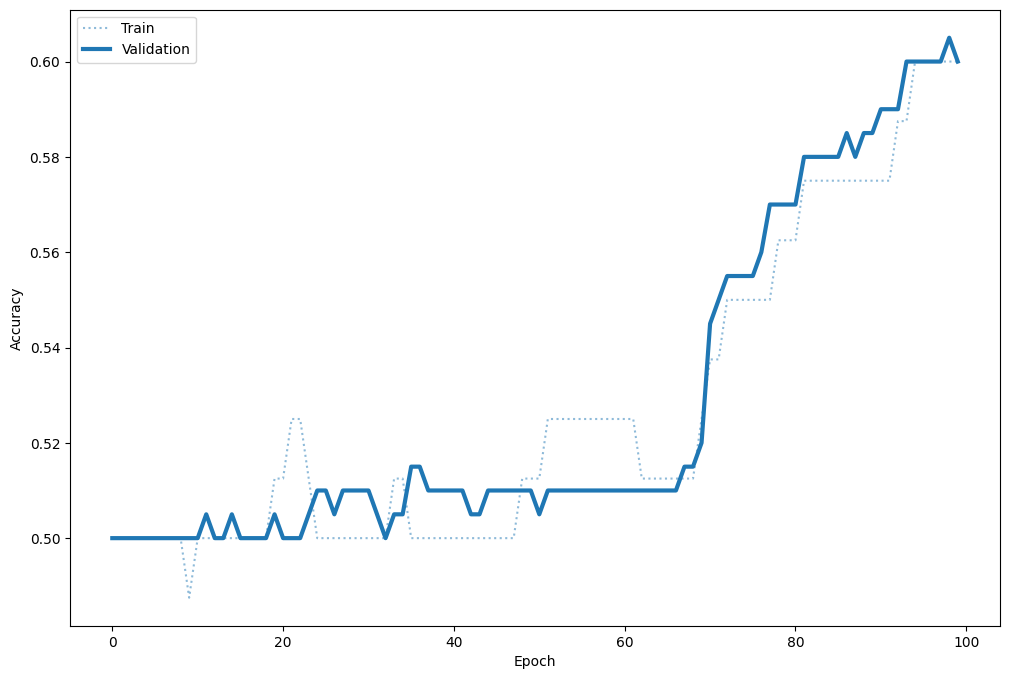

(<Figure size 1200x800 with 1 Axes>, <Axes: xlabel='Epoch', ylabel='Accuracy'>)

In [141]:
from counterfactual_alignment.utilities import plot_results

path = "/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/Projects/FACE_2D/outputs/Circles/"

plot_results([
    'MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80',
              ],
            path=path,
            )

limiting to random subsample of X


In [142]:


ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80


In [143]:

randints = np.random.choice(len(train.X),)

X = train.X[randints]
Y = train.Y[randints]

In [144]:

for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + "SUBSAMPLE" + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





  2%|▏         | 2/100 [00:00<00:15,  6.28it/s]

Train | Loss: 0.691935, Accuracy: 50.00%
Validation | Loss: 0.691909, Accuracy: 50.00%
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80
Train | Loss: 0.691911, Accuracy: 51.25%
Validation | Loss: 0.691887, Accuracy: 50.00%


  4%|▍         | 4/100 [00:00<00:15,  6.37it/s]

Train | Loss: 0.691895, Accuracy: 51.25%
Validation | Loss: 0.691874, Accuracy: 50.00%
Train | Loss: 0.691889, Accuracy: 50.00%
Validation | Loss: 0.69187, Accuracy: 50.00%


  5%|▌         | 5/100 [00:00<00:18,  5.07it/s]

...

Train | Loss: 0.721372, Accuracy: 50.00%
Validation | Loss: 0.721517, Accuracy: 50.00%
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80
Train | Loss: 0.721944, Accuracy: 50.00%
Validation | Loss: 0.722089, Accuracy: 50.00%


 99%|█████████▉| 99/100 [00:16<00:00,  6.21it/s]

Train | Loss: 0.722521, Accuracy: 50.00%
Validation | Loss: 0.722666, Accuracy: 50.00%
Train | Loss: 0.723102, Accuracy: 50.00%
Validation | Loss: 0.723248, Accuracy: 50.00%


100%|██████████| 100/100 [00:16<00:00,  6.18it/s]

Train | Loss: 0.723686, Accuracy: 50.00%
Validation | Loss: 0.723835, Accuracy: 50.00%
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_multiclass_cross_entropy_alpha_0.5__SIZE80


### Now adding K

In [145]:
loss_name ='combined_loss'

ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_Circles_filtered__LOSS_combined_loss_alpha_0.5__SIZE80


TypeError: cannot unpack non-iterable TrainState object

In [ ]:

for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + 'SUBSAMPLEwithK' + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 10%|█         | 1/10 [00:00<00:02,  3.78it/s]

Train Loss: 0.6817436218261719, Train Accuracy: 33.333335876464844
Validation Loss: 0.6814360618591309, Validation Accuracy: 52.499996185302734
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


 20%|██        | 2/10 [00:00<00:02,  3.84it/s]

Train Loss: 0.6531524658203125, Train Accuracy: 66.66667175292969
Validation Loss: 0.6595428586006165, Validation Accuracy: 83.5


 30%|███       | 3/10 [00:00<00:01,  3.87it/s]

...

Train Loss: 0.4943331182003021, Train Accuracy: 100.0
Validation Loss: 0.5649870038032532, Validation Accuracy: 91.5


 90%|█████████ | 9/10 [00:02<00:00,  3.90it/s]

Train Loss: 0.47055673599243164, Train Accuracy: 100.0
Validation Loss: 0.5532320141792297, Validation Accuracy: 88.5


100%|██████████| 10/10 [00:02<00:00,  3.87it/s]

Train Loss: 0.44708359241485596, Train Accuracy: 100.0
Validation Loss: 0.542171835899353, Validation Accuracy: 87.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


### NOW just with X from K

In [ ]:
loss_name ='cross_entropy'

ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


In [ ]:
X = np.concatenate((X,breadcrumbs['origins']))
Y = np.concatenate((Y,breadcrumbs['labels']))


for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + "SUBSAMPLEwithX" + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 20%|██        | 2/10 [00:00<00:01,  5.58it/s]

Train Loss: 0.6747066378593445, Train Accuracy: 66.66667175292969
Validation Loss: 0.666001558303833, Validation Accuracy: 94.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3
Train Loss: 0.6414563655853271, Train Accuracy: 66.66667175292969
Validation Loss: 0.6305109262466431, Validation Accuracy: 93.0


 40%|████      | 4/10 [00:00<00:00,  6.45it/s]

Train Loss: 0.6104416251182556, Train Accuracy: 66.66667175292969
Validation Loss: 0.5982265472412109, Validation Accuracy: 91.99999237060547
Train Loss: 0.5823225975036621, Train Accuracy: 66.66667175292969
Validation Loss: 0.5685110092163086, Validation Accuracy: 92.49999237060547


 50%|█████     | 5/10 [00:00<00:00,  5.81it/s]

...

Validation Loss: 0.5148662328720093, Validation Accuracy: 91.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3
Train Loss: 0.5101596117019653, Train Accuracy: 66.66667175292969
Validation Loss: 0.4900912344455719, Validation Accuracy: 91.5


 80%|████████  | 8/10 [00:01<00:00,  6.07it/s]

Train Loss: 0.48919588327407837, Train Accuracy: 66.66667175292969
Validation Loss: 0.4664055407047272, Validation Accuracy: 91.5
Train Loss: 0.4693925082683563, Train Accuracy: 66.66667175292969


100%|██████████| 10/10 [00:01<00:00,  5.84it/s]

Validation Loss: 0.44351959228515625, Validation Accuracy: 91.5
Train Loss: 0.45025551319122314, Train Accuracy: 66.66667175292969
Validation Loss: 0.4213413894176483, Validation Accuracy: 91.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


### And finally both

In [ ]:
loss_name ='combined_loss'

ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


In [ ]:
X = np.concatenate((X,breadcrumbs['origins']))
Y = np.concatenate((Y,breadcrumbs['labels']))


for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + "SUBSAMPLE_BOTH" + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 10%|█         | 1/10 [00:00<00:02,  3.70it/s]

Train Loss: 0.6741170883178711, Train Accuracy: 66.66667175292969
Validation Loss: 0.6667077541351318, Validation Accuracy: 94.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


 20%|██        | 2/10 [00:00<00:02,  3.74it/s]

Train Loss: 0.6399118304252625, Train Accuracy: 66.66667175292969
Validation Loss: 0.6321209669113159, Validation Accuracy: 93.0


 30%|███       | 3/10 [00:00<00:01,  3.77it/s]

...

Train Loss: 0.4910058379173279, Train Accuracy: 66.66667175292969
Validation Loss: 0.4813229739665985, Validation Accuracy: 91.5


 90%|█████████ | 9/10 [00:02<00:00,  3.74it/s]

Train Loss: 0.4750039577484131, Train Accuracy: 66.66667175292969
Validation Loss: 0.46226638555526733, Validation Accuracy: 91.0


100%|██████████| 10/10 [00:02<00:00,  3.73it/s]

Train Loss: 0.46093499660491943, Train Accuracy: 66.66667175292969
Validation Loss: 0.44446977972984314, Validation Accuracy: 91.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3
